In [1]:
!pip install -q ultralytics wandb opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [2]:
import os
import yaml
import cv2
import glob
from pathlib import Path
from ultralytics import YOLO
import wandb

wandb.login()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: fahrilsidik207 (fahrilsidik207-fzstudio) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
DATASET_SRC = '/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset'
WORKING_DIR = '/kaggle/working/'

In [6]:
def preprocess_and_verify_dataset(base_path):
    corrupted_files = 0
    total_images = 0
    
    for split in ['train', 'val', 'test']:
        img_path_pattern = os.path.join(base_path, split, 'images', '*')
        image_files = glob.glob(img_path_pattern)
        total_images += len(image_files)
        
        for img_path in image_files:
            img = cv2.imread(img_path)
            if img is None:
                print(f"[WARNING] Corrupt or damaged image found: {img_path}")
                corrupted_files += 1
                
    print(f"✔ Sanity Check Completed. Total: {total_images}")
    if corrupted_files == 0:
        print("✔ Good Data Quality: No corrupted images.")
    else:
        print(f"[WARNING] Found {corrupted_files} corrupted files.")

preprocess_and_verify_dataset(DATASET_SRC)

with open(os.path.join(DATASET_SRC, 'data.yaml'), 'r') as f:
    yaml_content = yaml.safe_load(f)

yaml_content['path'] = DATASET_SRC
yaml_content['train'] = 'train/images'
yaml_content['val'] = 'valid/images'
yaml_content['test'] = 'test/images'

kaggle_yaml_path = os.path.join(WORKING_DIR, 'ppe_pipeline_data.yaml')
with open(kaggle_yaml_path, 'w') as f:
    yaml.dump(yaml_content, f)

print("✔ Pipeline Data Routing")

✔ Sanity Check Completed. Total: 3654
✔ Good Data Quality: No corrupted images.
✔ Pipeline Data Routing


In [22]:
wandb.init(
    project="PPE-Industrial-Safety-CV",
    name="YOLOv10_End_to_End_Run",
    config={
        "framework": "Ultralytics YOLOv10",
        "epochs": 50,
        "batch_size": 16,
        "img_size": 640,
        "optimizer": "Auto"
    }
)

model = YOLO('yolov10n.pt')

print("➔ Starting the Model Training Loop...")
model.train(
    data=kaggle_yaml_path,
    epochs=50,
    batch=16,
    imgsz=640,
    device=0,  
    workers=4,
    save=True, 
    project="Safety_Project_Eng",
    name="yolov10_safety_run",
    
    mosaic=1.0,     
    hsv_v=0.4,      
    hsv_s=0.5,      
    degrees=15.0,     
    fliplr=0.5       
)

wandb.finish()
print("✔ Model Training Completed. Best weights saved.")

print("...")

path_best = "/kaggle/working/Safety_Project_Eng/yolov10_safety_run/weights/best.pt"
path_alternatif = "/kaggle/working/runs/detect/Safety_Project_Eng/yolov10_safety_run/weights/best.pt"
path_backup = "/kaggle/working/safety_best_model.pt"

if os.path.exists(path_best):
    shutil.copy(path_best, path_backup)
    print(f" done backup {path_backup}")
elif os.path.exists(path_alternatif):
    shutil.copy(path_alternatif, path_backup)
    print(f"🎉 done in folder: {path_backup}")
else:
    print("...")
    for root, dirs, files in os.walk("/kaggle/working"):
        if "best.pt" in files:
            foundt = os.path.join(root, "best.pt")
            shutil.copy(foundt, path_backup)
            print(f"🎉 done {foundt} to: {path_backup}")
            break

➔ Starting the Model Training Loop...
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/ppe_pipeline_data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10_safety_run-2, nbs=64, nms=False, opset=None, opt

✔ Model Training Completed. Best weights saved.
...
...
🎉 done /kaggle/working/runs/detect/Safety_Project_Eng/yolov10_safety_run-2/weights/best.pt to: /kaggle/working/safety_best_model.pt


In [23]:
print("➔ Starting Model Evaluation on the Test Set...")

best_model_weight = '/kaggle/working/safety_best_model.pt'
trained_model = YOLO(best_model_weight)

evaluation_results = trained_model.val(
    data=kaggle_yaml_path, 
    split='test',
    device=0
)

mAP50 = evaluation_results.box.map50
mAP50_95 = evaluation_results.box.map
precision = evaluation_results.box.mp
recall = evaluation_results.box.mr

print("\n=============================================")
print("   FINAL EVALUATION METRICS OF THE MODEL     ")
print("=============================================")
print(f" Precision : {precision:.4f}")
print(f" Recall  : {recall:.4f}")
print(f" mAP@0.5 : {mAP50:.4f}")
print(f" mAP@0.5:0.95  : {mAP50_95:.4f}")
print("=============================================")
print("➔")

➔ Starting Model Evaluation on the Test Set...
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,266,143 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 3.8±1.3 ms, read: 38.4±26.2 MB/s, size: 66.9 KB)
val: Scanning /kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/test/labels... 406 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 406/406 338.5it/s 1.2s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.6it/s 5.7s0.1s
                   all        406       2785       0.88      0.787      0.852      0.553
                helmet        270        529        0.9      0.814

...


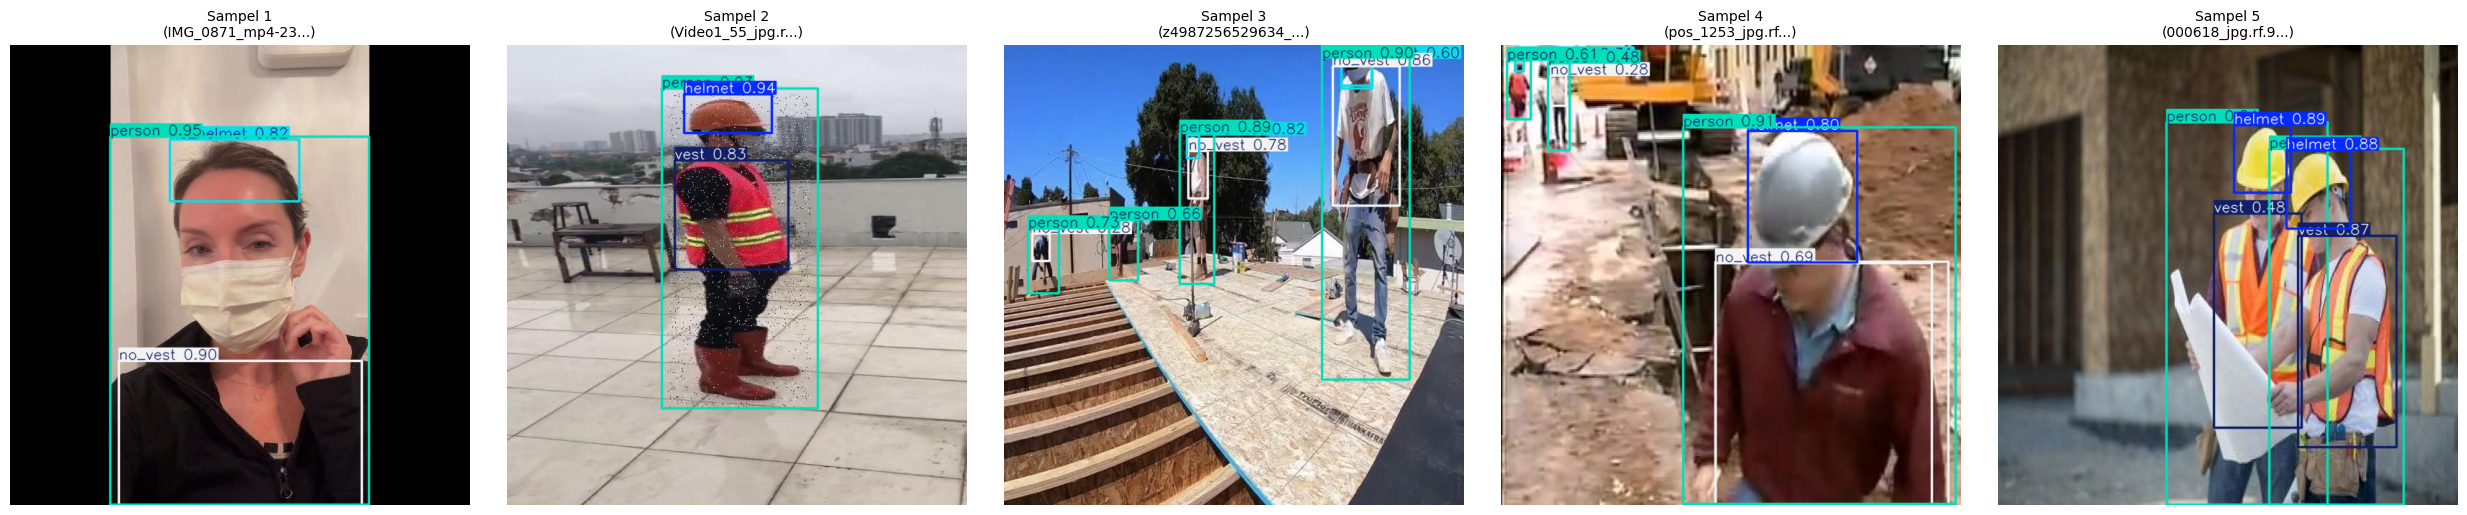

✔


In [28]:
best_model_weight = '/kaggle/working/safety_best_model.pt'
trained_model = YOLO(best_model_weight)

test_images_path = '/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/test/images/*'
sample_images = glob.glob(test_images_path)[:5] 

print("...")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, img_path in enumerate(sample_images):
    results = trained_model.predict(source=img_path, conf=0.25, save=False, verbose=False)
    result = results[0]
    
    annotated_img = result.plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(annotated_img_rgb)
    axes[idx].set_title(f"Sampel {idx+1}\n({os.path.basename(img_path)[:15]}...)", fontsize=10)
    axes[idx].axis('off')
    
plt.tight_layout()
plt.show()

print("✔")